### Verifying Project Root

In [ ]:
import sys
from pathlib import Path

# find project root (one level above notebooks/)
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: /Users/rnd4impact/Desktop/RND4IMPACT Projects/life-expectancy-analysis


### Imports + Load Data

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/main_dataset.csv")
df["year"] = pd.to_numeric(df["year"], errors="raise").astype(int)
df = df.dropna(subset=["life_expectancy"]).copy()

df_metrics= pd.read_csv("../outputs/metrics/week4_baseline_results.csv")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

## Region trend plot (median + IQR band)

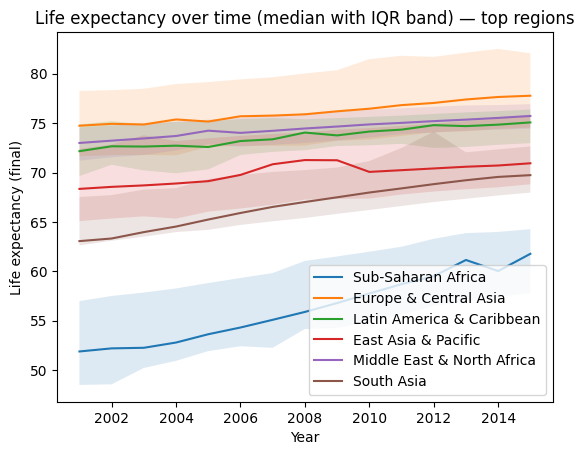

In [4]:
# requires region column; if missing, skip
if "region" in df.columns:
    g = df.groupby(["region", "year"])["life_expectancy"]
    trend = g.agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n="size"
    ).reset_index()

    # plot a few biggest regions (by row count) to avoid clutter
    top_regions = (
        df["region"].value_counts().head(6).index.tolist()
        if df["region"].notna().any() else []
    )
    plot_df = trend[trend["region"].isin(top_regions)].copy()

    plt.figure()
    for r in top_regions:
        sub = plot_df[plot_df["region"] == r]
        plt.plot(sub["year"], sub["median"], label=r)
        plt.fill_between(sub["year"], sub["q25"], sub["q75"], alpha=0.15)

    plt.title("Life expectancy over time (median with IQR band) — top regions")
    plt.xlabel("Year")
    plt.ylabel("Life expectancy (final)")
    plt.legend()
    plt.show()

The improvement over time indicates global health development, but persistent regional gaps show structural inequality in healthcare access, sanitation, and economic conditions.

## Region Boxplot

/var/folders/z1/h4t_14t16kx2dlrnwd603z8c0000gn/T/ipykernel_73201/653667908.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_regions, vert=True, showfliers=False)


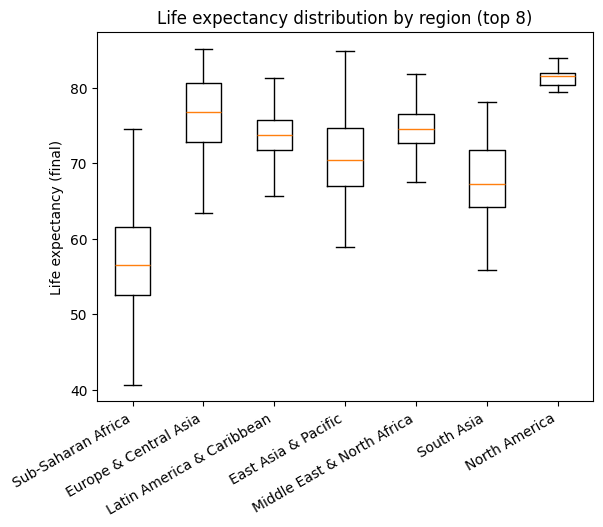

In [5]:
if "region" in df.columns:
    # keep top 8 regions for readability
    top_regions = df["region"].value_counts().head(8).index.tolist()
    sub = df[df["region"].isin(top_regions)].copy()

    data = [sub[sub["region"] == r]["life_expectancy"].values for r in top_regions]

    plt.figure()
    plt.boxplot(data, labels=top_regions, vert=True, showfliers=False)
    plt.xticks(rotation=30, ha="right")
    plt.title("Life expectancy distribution by region (top 8)")
    plt.ylabel("Life expectancy (final)")
    plt.show()

### Sub-Saharan Africa:

- lowest median
- largest spread

*Meaning*:
Some countries doing okay, others extremely poor health conditions.

### Europe:

- high median
- tight distribution

*Meaning*:
Consistent healthcare systems and infrastructure.

## GDP vs Life Expectancy (log)

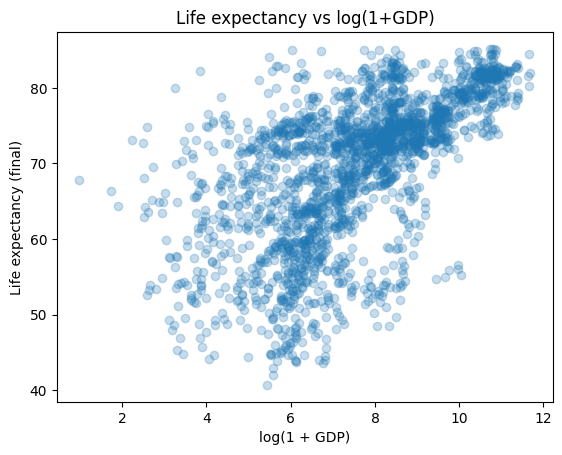

In [ ]:
sub = df.dropna(subset=["gdp"]).copy()
sub["log_gdp"] = np.log1p(sub["gdp"])

plt.figure()
sns.kdeplot(
    data=df,
    x="schooling",
    y="life_expectancy",
    fill=True
)
plt.title("Density of Schooling vs Life Expectancy")
plt.show()
plt.title("Life expectancy vs log(1+GDP)")
plt.xlabel("log(1 + GDP)")
plt.ylabel("Life expectancy (final)")
plt.show()

First off, GDP is extremely skewed, so we log transform to compress scale so relationships become visible. This is one of the most famous relationship in development economics where wealthier countries live longer. However we can see from this plot that this relationship is not linear. At low GDP small income increases give huge life expectancy gains. At high GDP we see a plateau. After a certain level of wealth, additional money does NOT translate into health improvement.

## Schooling vs Life Expectancy

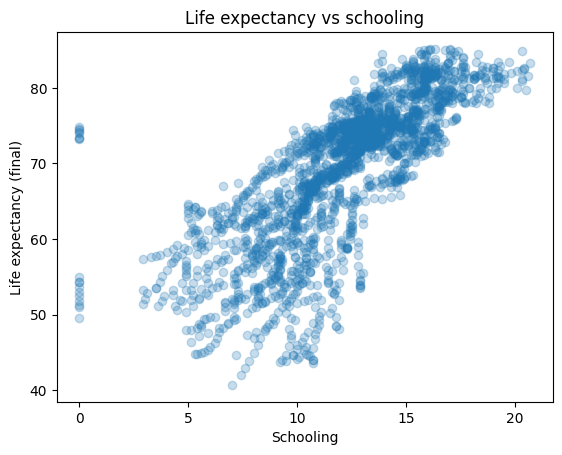

In [7]:
if "schooling" in df.columns:
    sub = df.dropna(subset=["schooling"]).copy()
    plt.figure()
    plt.scatter(sub["schooling"], sub["life_expectancy"], alpha=0.25)
    plt.title("Life expectancy vs schooling")
    plt.xlabel("Schooling")
    plt.ylabel("Life expectancy (final)")
    plt.show()

There is a clear positive relationship. Education affects:

- hygiene
- health awareness
- fertility rates
- healthcare usage
- nutrition

We can see how education can predict life expectancy better than GDP in development research.

## Correlation Heatmap (reduced predictors)

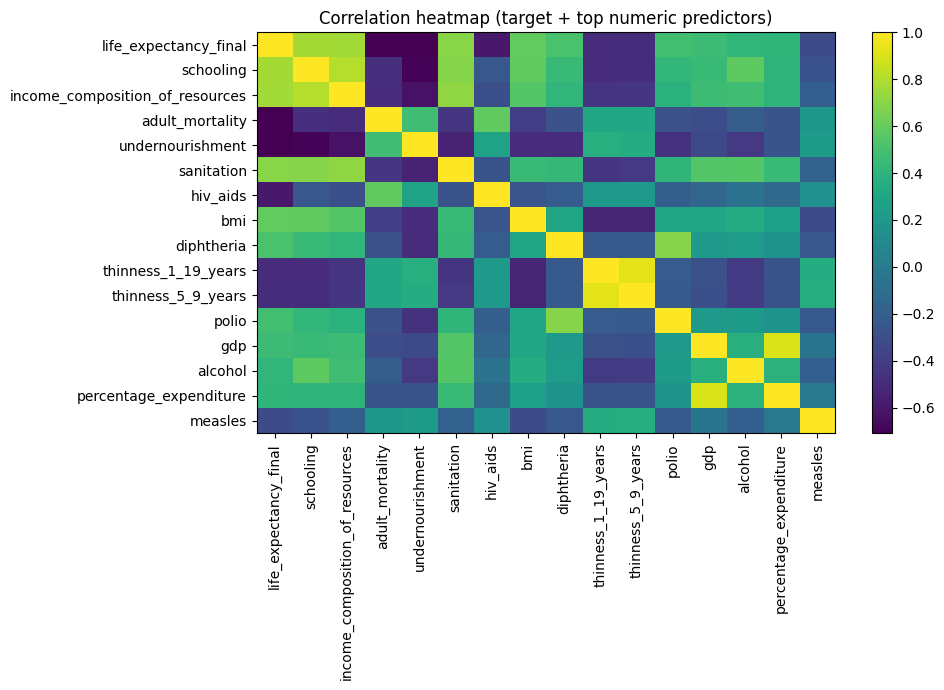

In [8]:
# pick numeric columns only, drop target-derived columns if present
drop_cols = [c for c in ["life_expectancy", "life_expectancy_wb"] if c in df.columns]
num_df = df.drop(columns=drop_cols, errors="ignore").select_dtypes(include=["number"]).copy()

# keep a manageable set: top 15 most correlated with target
corr = num_df.corr(numeric_only=True)["life_expectancy"].sort_values(key=lambda s: s.abs(), ascending=False)
top = [c for c in corr.index.tolist() if c != "life_expectancy"][:15]
heat_cols = ["life_expectancy"] + top

corr_mat = num_df[heat_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_mat, aspect="auto")
plt.xticks(range(len(heat_cols)), heat_cols, rotation=90)
plt.yticks(range(len(heat_cols)), heat_cols)
plt.title("Correlation heatmap (target + top numeric predictors)")
plt.colorbar()
plt.tight_layout()
plt.show()

### Strong positive correlations:

- schooling
- income composition
- sanitation

### Strong negative correlations:

- adult mortality
- HIV/AIDS
- undernourishment

## RMSE/MAE/R² by model (per split)

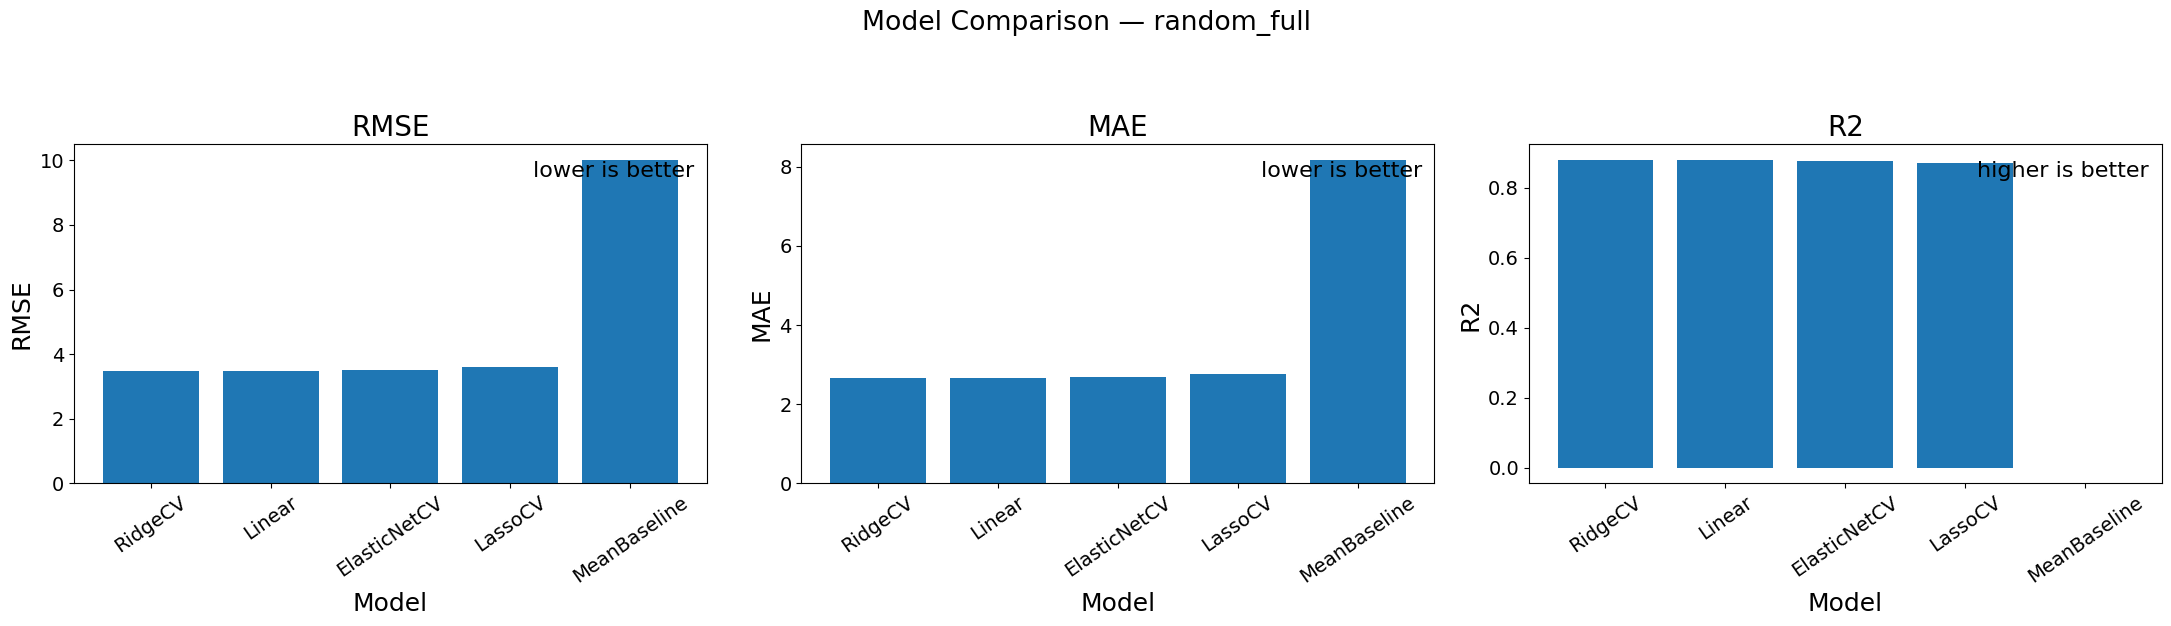

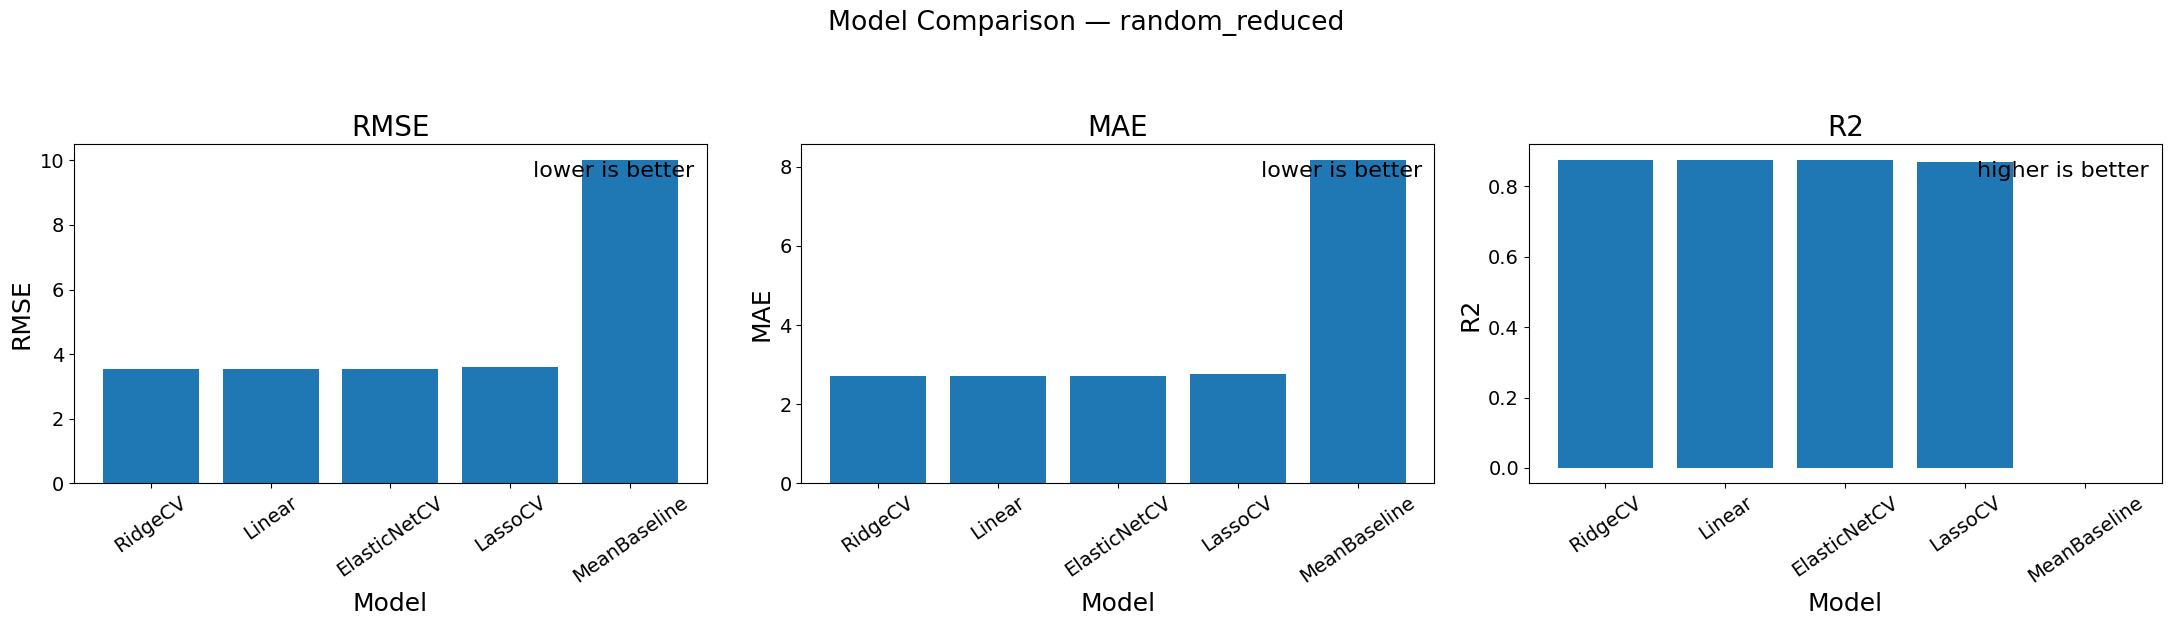

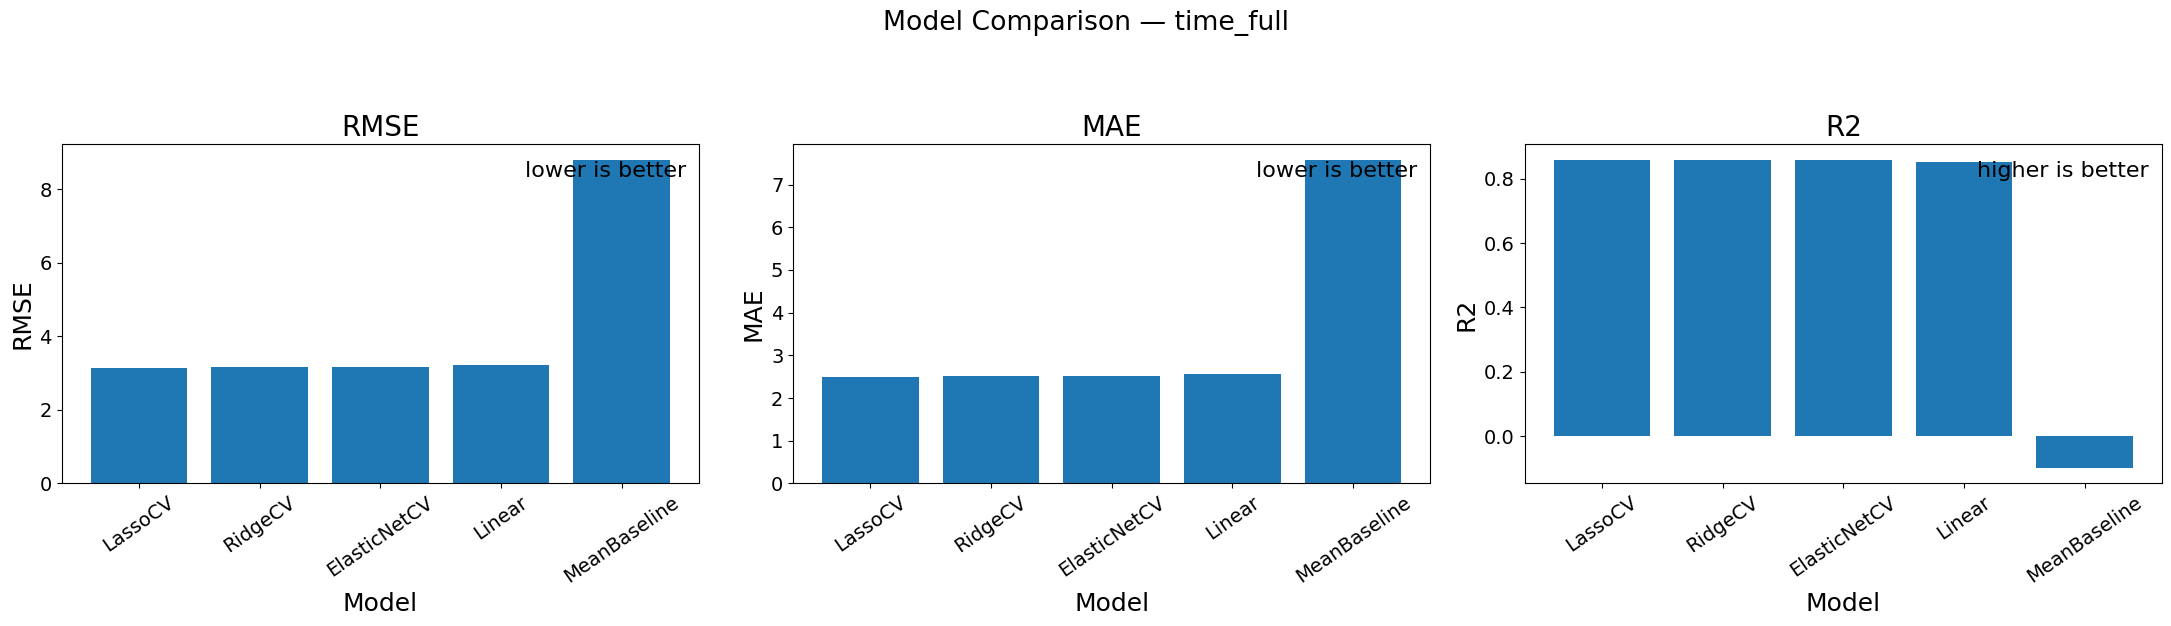

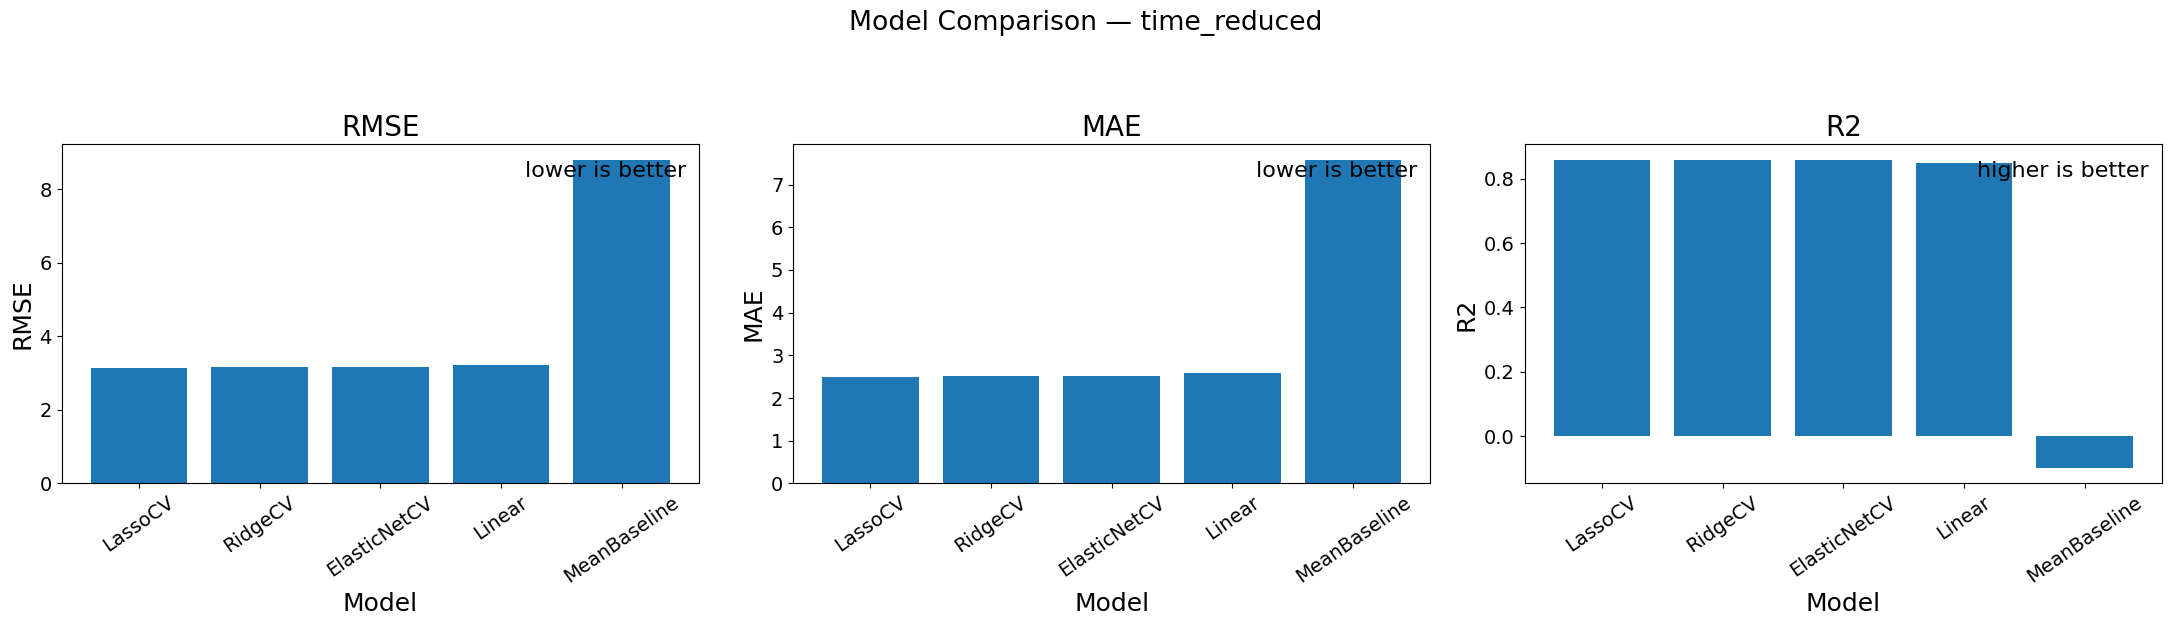

In [10]:
metrics = ["rmse", "mae", "r2"]
splits = sorted(df_metrics["split_name"].unique())

for split in splits:
    sub = df_metrics[df_metrics["split_name"] == split].copy()
    sub = sub.sort_values("rmse")  # best first (lower RMSE is better)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f"Model Comparison — {split}", y=1.05)

    for ax, m in zip(axes, metrics):
        ax.bar(sub["model_name"], sub[m])
        ax.set_title(m.upper())
        ax.set_xlabel("Model")
        ax.set_ylabel(m.upper())
        ax.tick_params(axis="x", rotation=35)

        # helpful note on direction
        if m in ["rmse", "mae"]:
            ax.text(0.98, 0.95, "lower is better", transform=ax.transAxes,
                    ha="right", va="top")
        else:
            ax.text(0.98, 0.95, "higher is better", transform=ax.transAxes,
                    ha="right", va="top")

    plt.tight_layout()
    plt.show()

## Heatmap: Model ranking across splits

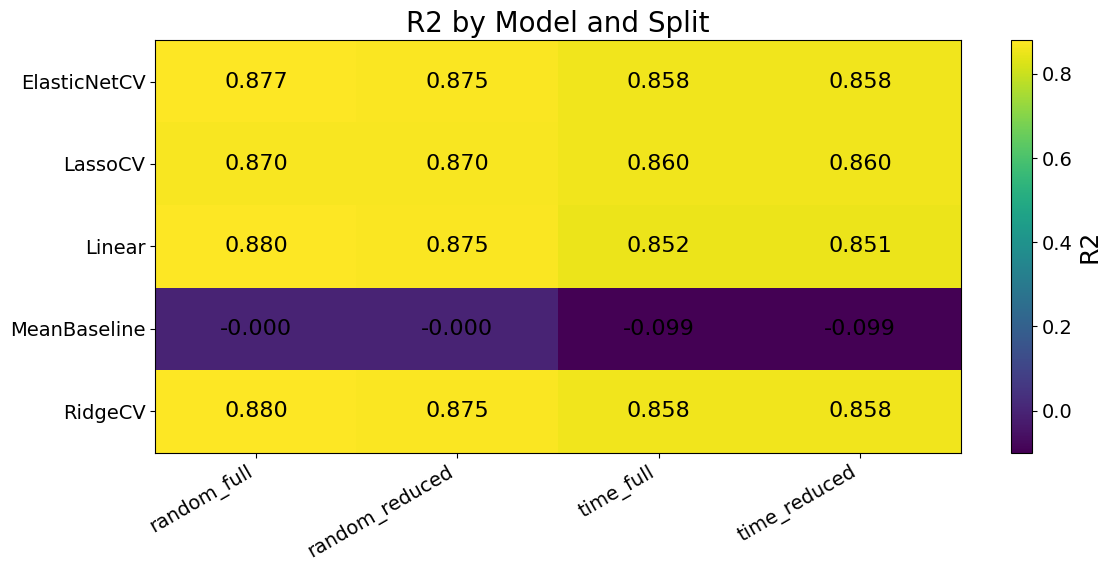

In [13]:
rank_metric = "r2"  # "mae" or "r2" too

pivot = df_metrics.pivot(index="model_name", columns="split_name", values=rank_metric)

plt.figure(figsize=(12, 6))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=30, ha="right")
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.title(f"{rank_metric.upper()} by Model and Split")
cbar = plt.colorbar()
cbar.set_label(rank_metric.upper())

# annotate values
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        plt.text(j, i, f"{val:.3f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## “Generalization gap” plot: Time split vs Random split

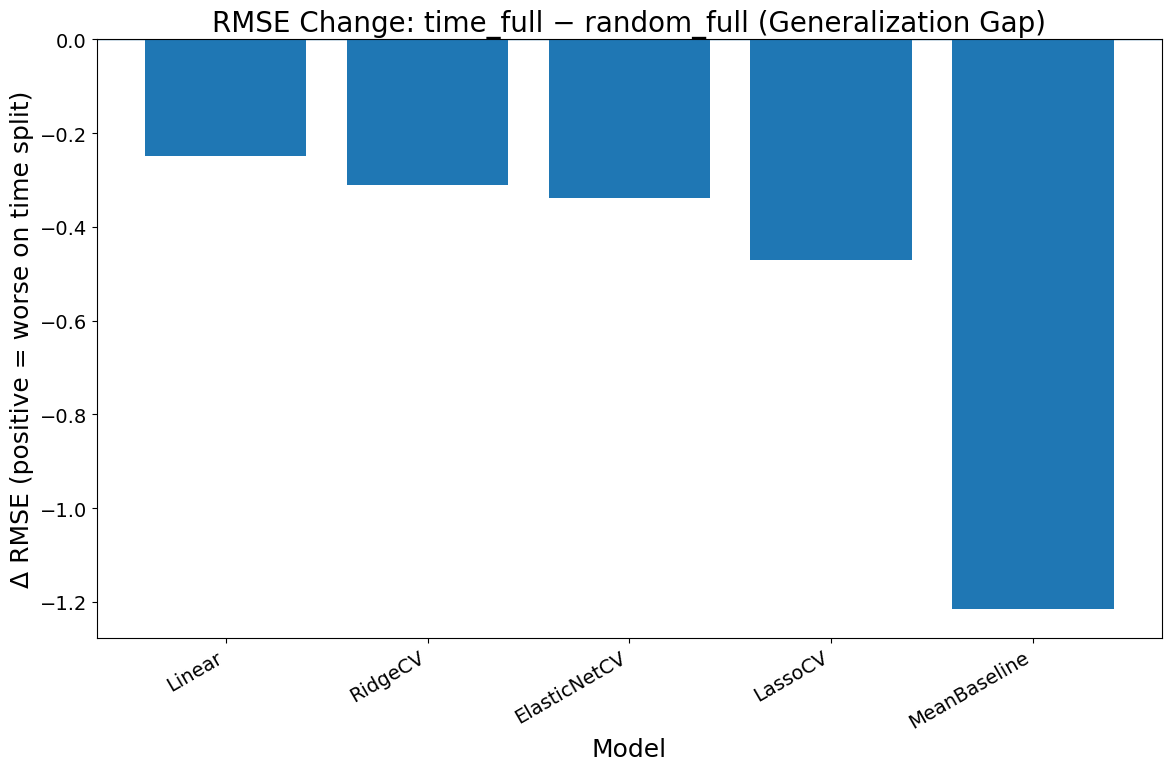

In [ ]:
split_a = "random_full"
split_b = "time_full"

a = df_metrics[df_metrics["split_name"] == split_a][["model_name", "rmse"]].rename(columns={"rmse": "rmse_a"})
b = df_metrics[df_metrics["split_name"] == split_b][["model_name", "rmse"]].rename(columns={"rmse": "rmse_b"})

merged = a.merge(b, on="model_name", how="inner")
merged["delta_rmse"] = merged["rmse_b"] - merged["rmse_a"]  
merged = merged.sort_values("delta_rmse", ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(merged["model_name"], merged["delta_rmse"])
plt.axhline(0, linewidth=1)
plt.title(f"RMSE Change: {split_b} − {split_a} (Generalization Gap)")
plt.xlabel("Model")
plt.ylabel("Δ RMSE (positive = worse on time split)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()